In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Predicting Bus Fuel Consumption for Operational Efficiency") \
    .getOrCreate()

In [2]:
df = spark.read.csv(
    r"C:\Users\ASUS\Documents\Bus project\data\bus_fuel_consumption_114k.csv",
    header=True,
    inferSchema=True
)

df.show(5)

+----------------+------------+---------+--------+---------------+--------------+---------+--------+-------+-------------+-------------+-------------+----------------+----------------+
|        Operator|Service_Code|Line_Name|Distance|Number_of_Stops|Departure_Hour|Peak_Hour|Day_Type|Weather|Traffic_Level|Delay_Minutes|Average_Speed|Fuel_Consumption|Efficiency_Class|
+----------------+------------+---------+--------+---------------+--------------+---------+--------+-------+-------------+-------------+-------------+----------------+----------------+
|Stagecoach South|PK0002571:21|       46|     437|            264|             7|        1| Weekday|   Rain|         High|           17|           40|          210.65|             Low|
|Stagecoach South|PK0002571:21|       46|     437|            264|             7|        1| Weekday|   Rain|         High|           13|           39|          209.38|          Medium|
|Stagecoach South|PK0002571:21|       46|     437|            264|         

In [3]:
df.printSchema()

print("Rows :", df.count())

print("Columns :", len(df.columns))

root
 |-- Operator: string (nullable = true)
 |-- Service_Code: string (nullable = true)
 |-- Line_Name: string (nullable = true)
 |-- Distance: integer (nullable = true)
 |-- Number_of_Stops: integer (nullable = true)
 |-- Departure_Hour: integer (nullable = true)
 |-- Peak_Hour: integer (nullable = true)
 |-- Day_Type: string (nullable = true)
 |-- Weather: string (nullable = true)
 |-- Traffic_Level: string (nullable = true)
 |-- Delay_Minutes: integer (nullable = true)
 |-- Average_Speed: integer (nullable = true)
 |-- Fuel_Consumption: double (nullable = true)
 |-- Efficiency_Class: string (nullable = true)

Rows : 114000
Columns : 14


In [4]:
df.show(10, truncate=False)

+----------------+------------+---------+--------+---------------+--------------+---------+--------+-------+-------------+-------------+-------------+----------------+----------------+
|Operator        |Service_Code|Line_Name|Distance|Number_of_Stops|Departure_Hour|Peak_Hour|Day_Type|Weather|Traffic_Level|Delay_Minutes|Average_Speed|Fuel_Consumption|Efficiency_Class|
+----------------+------------+---------+--------+---------------+--------------+---------+--------+-------+-------------+-------------+-------------+----------------+----------------+
|Stagecoach South|PK0002571:21|46       |437     |264            |7             |1        |Weekday |Rain   |High         |17           |40           |210.65          |Low             |
|Stagecoach South|PK0002571:21|46       |437     |264            |7             |1        |Weekday |Rain   |High         |13           |39           |209.38          |Medium          |
|Stagecoach South|PK0002571:21|46       |437     |264            |7        

In [5]:
# ============================================
# Big Data Analytics for Bus Fuel Consumption Prediction
# ============================================

from pyspark.sql import SparkSession
from pyspark.sql.functions import *

from pyspark.ml.feature import (
    StringIndexer,
    OneHotEncoder,
    VectorAssembler
)

from pyspark.ml.regression import (
    LinearRegression,
    DecisionTreeRegressor,
    RandomForestRegressor
)

from pyspark.ml.evaluation import RegressionEvaluator

In [6]:
print(df.columns)

['Operator', 'Service_Code', 'Line_Name', 'Distance', 'Number_of_Stops', 'Departure_Hour', 'Peak_Hour', 'Day_Type', 'Weather', 'Traffic_Level', 'Delay_Minutes', 'Average_Speed', 'Fuel_Consumption', 'Efficiency_Class']


In [7]:
from pyspark.sql.functions import col, when, count

missing = df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
])

missing.show()

+--------+------------+---------+--------+---------------+--------------+---------+--------+-------+-------------+-------------+-------------+----------------+----------------+
|Operator|Service_Code|Line_Name|Distance|Number_of_Stops|Departure_Hour|Peak_Hour|Day_Type|Weather|Traffic_Level|Delay_Minutes|Average_Speed|Fuel_Consumption|Efficiency_Class|
+--------+------------+---------+--------+---------------+--------------+---------+--------+-------+-------------+-------------+-------------+----------------+----------------+
|       0|           0|        0|       0|              0|             0|        0|       0|      0|            0|            0|            0|               0|               0|
+--------+------------+---------+--------+---------------+--------------+---------+--------+-------+-------------+-------------+-------------+----------------+----------------+



In [8]:
total_rows = df.count()
unique_rows = df.dropDuplicates().count()

print("Total Rows:", total_rows)
print("Unique Rows:", unique_rows)
print("Duplicate Rows:", total_rows - unique_rows)

Total Rows: 114000
Unique Rows: 113936
Duplicate Rows: 64


In [9]:
df.describe().show()

+-------+----------------+-------------+------------------+-----------------+------------------+------------------+-------------------+--------+-------+-------------+-----------------+------------------+------------------+----------------+
|summary|        Operator| Service_Code|         Line_Name|         Distance|   Number_of_Stops|    Departure_Hour|          Peak_Hour|Day_Type|Weather|Traffic_Level|    Delay_Minutes|     Average_Speed|  Fuel_Consumption|Efficiency_Class|
+-------+----------------+-------------+------------------+-----------------+------------------+------------------+-------------------+--------+-------+-------------+-----------------+------------------+------------------+----------------+
|  count|          114000|       114000|            114000|           114000|            114000|            114000|             114000|  114000| 114000|       114000|           114000|            114000|            114000|          114000|
|   mean|            NULL|         NULL|

In [10]:
df = df.dropDuplicates()

print("Rows after removing duplicates:", df.count())

Rows after removing duplicates: 113936


In [11]:
total_rows = df.count()
unique_rows = df.dropDuplicates().count()

print("Total Rows:", total_rows)
print("Unique Rows:", unique_rows)
print("Duplicate Rows:", total_rows - unique_rows)

Total Rows: 113936
Unique Rows: 113936
Duplicate Rows: 0


In [12]:
from pyspark.sql.functions import desc

df.groupBy("Operator") \
    .count() \
    .orderBy(desc("count")) \
    .show(10, truncate=False)

+----------------+------+
|Operator        |count |
+----------------+------+
|Stagecoach South|113936|
+----------------+------+



In [13]:
from pyspark.sql.functions import avg, round

df.groupBy("Weather") \
    .agg(
        round(avg("Fuel_Consumption"), 2).alias("Average_Fuel_Consumption")
    ) \
    .show()

+-------+------------------------+
|Weather|Average_Fuel_Consumption|
+-------+------------------------+
|    Fog|                  412.34|
|  Clear|                  366.48|
|   Rain|                  406.02|
+-------+------------------------+



In [14]:
df.groupBy("Traffic_Level") \
    .agg(
        round(avg("Fuel_Consumption"), 2).alias("Average_Fuel_Consumption")
    ) \
    .show()

+-------------+------------------------+
|Traffic_Level|Average_Fuel_Consumption|
+-------------+------------------------+
|         High|                  430.49|
|          Low|                  306.52|
|       Medium|                  351.84|
+-------------+------------------------+



In [15]:
df.groupBy("Traffic_Level") \
    .agg(
        round(avg("Delay_Minutes"), 2).alias("Average_Delay")
    ) \
    .show()

+-------------+-------------+
|Traffic_Level|Average_Delay|
+-------------+-------------+
|         High|        19.82|
|          Low|          3.8|
|       Medium|          9.3|
+-------------+-------------+



In [16]:
df.groupBy("Peak_Hour") \
    .agg(
        round(avg("Fuel_Consumption"), 2).alias("Average_Fuel_Consumption")
    ) \
    .show()

+---------+------------------------+
|Peak_Hour|Average_Fuel_Consumption|
+---------+------------------------+
|        1|                   406.5|
|        0|                  313.94|
+---------+------------------------+



In [17]:
df.groupBy("Weather") \
    .count() \
    .show()

+-------+-----+
|Weather|count|
+-------+-----+
|    Fog|11440|
|  Clear|68278|
|   Rain|34218|
+-------+-----+



In [18]:
df.groupBy("Traffic_Level") \
    .count() \
    .show()

+-------------+-----+
|Traffic_Level|count|
+-------------+-----+
|         High|56668|
|          Low|20120|
|       Medium|37148|
+-------------+-----+



In [19]:
numeric_columns = [
    "Distance",
    "Number_of_Stops",
    "Delay_Minutes",
    "Average_Speed",
    "Fuel_Consumption"
]

for col_name in numeric_columns[:-1]:
    corr = df.stat.corr(col_name, "Fuel_Consumption")
    print(f"{col_name} vs Fuel_Consumption = {corr:.3f}")

Distance vs Fuel_Consumption = 0.991
Number_of_Stops vs Fuel_Consumption = -0.102
Delay_Minutes vs Fuel_Consumption = 0.058
Average_Speed vs Fuel_Consumption = -0.055


In [20]:
df.printSchema()

root
 |-- Operator: string (nullable = true)
 |-- Service_Code: string (nullable = true)
 |-- Line_Name: string (nullable = true)
 |-- Distance: integer (nullable = true)
 |-- Number_of_Stops: integer (nullable = true)
 |-- Departure_Hour: integer (nullable = true)
 |-- Peak_Hour: integer (nullable = true)
 |-- Day_Type: string (nullable = true)
 |-- Weather: string (nullable = true)
 |-- Traffic_Level: string (nullable = true)
 |-- Delay_Minutes: integer (nullable = true)
 |-- Average_Speed: integer (nullable = true)
 |-- Fuel_Consumption: double (nullable = true)
 |-- Efficiency_Class: string (nullable = true)



In [21]:
from pyspark.ml.feature import StringIndexer

operator_indexer = StringIndexer(
    inputCol="Operator",
    outputCol="Operator_Index",
    handleInvalid="keep"
)

weather_indexer = StringIndexer(
    inputCol="Weather",
    outputCol="Weather_Index",
    handleInvalid="keep"
)

traffic_indexer = StringIndexer(
    inputCol="Traffic_Level",
    outputCol="Traffic_Index",
    handleInvalid="keep"
)

day_indexer = StringIndexer(
    inputCol="Day_Type",
    outputCol="Day_Index",
    handleInvalid="keep"
)

In [22]:
df = operator_indexer.fit(df).transform(df)
df = weather_indexer.fit(df).transform(df)
df = traffic_indexer.fit(df).transform(df)
df = day_indexer.fit(df).transform(df)

In [23]:
df.select(
    "Operator",
    "Operator_Index",
    "Weather",
    "Weather_Index",
    "Traffic_Level",
    "Traffic_Index",
    "Day_Type",
    "Day_Index"
).show(10, truncate=False)

+----------------+--------------+-------+-------------+-------------+-------------+--------+---------+
|Operator        |Operator_Index|Weather|Weather_Index|Traffic_Level|Traffic_Index|Day_Type|Day_Index|
+----------------+--------------+-------+-------------+-------------+-------------+--------+---------+
|Stagecoach South|0.0           |Rain   |1.0          |High         |0.0          |Weekday |0.0      |
|Stagecoach South|0.0           |Fog    |2.0          |Low          |2.0          |Weekday |0.0      |
|Stagecoach South|0.0           |Clear  |0.0          |High         |0.0          |Weekday |0.0      |
|Stagecoach South|0.0           |Clear  |0.0          |Medium       |1.0          |Weekday |0.0      |
|Stagecoach South|0.0           |Rain   |1.0          |Medium       |1.0          |Weekday |0.0      |
|Stagecoach South|0.0           |Clear  |0.0          |Medium       |1.0          |Weekday |0.0      |
|Stagecoach South|0.0           |Fog    |2.0          |Low          |2.0 

In [24]:
feature_columns = [
    "Distance",
    "Number_of_Stops",
    "Departure_Hour",
    "Peak_Hour",
    "Delay_Minutes",
    "Average_Speed",
    "Operator_Index",
    "Weather_Index",
    "Traffic_Index",
    "Day_Index"
]

In [25]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

df = assembler.transform(df)

In [26]:
df.select(
    "features",
    "Fuel_Consumption"
).show(5, truncate=False)

+------------------------------------------------+----------------+
|features                                        |Fuel_Consumption|
+------------------------------------------------+----------------+
|[437.0,264.0,7.0,1.0,19.0,35.0,0.0,1.0,0.0,0.0] |209.81          |
|[437.0,109.0,7.0,1.0,8.0,50.0,0.0,2.0,2.0,0.0]  |158.65          |
|[721.0,3854.0,7.0,1.0,16.0,40.0,0.0,0.0,0.0,0.0]|393.67          |
|[721.0,3854.0,7.0,1.0,7.0,46.0,0.0,0.0,1.0,0.0] |335.09          |
|[721.0,3854.0,7.0,1.0,12.0,46.0,0.0,1.0,1.0,0.0]|359.41          |
+------------------------------------------------+----------------+
only showing top 5 rows


In [27]:
train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)

print("Training Rows :", train_data.count())
print("Testing Rows :", test_data.count())

Training Rows : 91335
Testing Rows : 22601


In [28]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(
    featuresCol="features",
    labelCol="Fuel_Consumption"
)

lr_model = lr.fit(train_data)

In [29]:
lr_predictions = lr_model.transform(test_data)

lr_predictions.select(
    "Fuel_Consumption",
    "prediction"
).show(10, truncate=False)

+----------------+------------------+
|Fuel_Consumption|prediction        |
+----------------+------------------+
|147.03          |158.02065001937353|
|145.52          |158.26063589586704|
|148.5           |158.97994636410505|
|152.39          |159.73914661821823|
|148.08          |159.85946313708624|
|148.3           |161.69762909355646|
|113.2           |46.68365124531062 |
|124.73          |102.21253638177899|
|159.98          |182.42135092751744|
|153.87          |183.42053705812415|
+----------------+------------------+
only showing top 10 rows


In [30]:
from pyspark.ml.evaluation import RegressionEvaluator

rmse_evaluator = RegressionEvaluator(
    labelCol="Fuel_Consumption",
    predictionCol="prediction",
    metricName="rmse"
)

mae_evaluator = RegressionEvaluator(
    labelCol="Fuel_Consumption",
    predictionCol="prediction",
    metricName="mae"
)

r2_evaluator = RegressionEvaluator(
    labelCol="Fuel_Consumption",
    predictionCol="prediction",
    metricName="r2"
)

lr_rmse = rmse_evaluator.evaluate(lr_predictions)
lr_mae = mae_evaluator.evaluate(lr_predictions)
lr_r2 = r2_evaluator.evaluate(lr_predictions)

print("Linear Regression Results")
print("RMSE =", lr_rmse)
print("MAE  =", lr_mae)
print("R²   =", lr_r2)

Linear Regression Results
RMSE = 89.20656425133815
MAE  = 30.762759798020173
R²   = 0.9884348432003315


In [31]:
from pyspark.ml.regression import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    featuresCol="features",
    labelCol="Fuel_Consumption",
    maxDepth=8,
    seed=42
)

dt_model = dt.fit(train_data)

In [32]:
dt_predictions = dt_model.transform(test_data)

In [33]:
dt_rmse = rmse_evaluator.evaluate(dt_predictions)
dt_mae = mae_evaluator.evaluate(dt_predictions)
dt_r2 = r2_evaluator.evaluate(dt_predictions)

print("Decision Tree Results")
print("RMSE =", dt_rmse)
print("MAE  =", dt_mae)
print("R²   =", dt_r2)

Decision Tree Results
RMSE = 48.810046072671916
MAE  = 20.8890988610486
R²   = 0.9965376072127355


In [34]:
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="Fuel_Consumption",
    numTrees=100,
    maxDepth=10,
    seed=42
)

rf_model = rf.fit(train_data)

In [35]:
rf_predictions = rf_model.transform(test_data)

In [36]:
rf_rmse = rmse_evaluator.evaluate(rf_predictions)
rf_mae = mae_evaluator.evaluate(rf_predictions)
rf_r2 = r2_evaluator.evaluate(rf_predictions)

print("Random Forest Results")
print("RMSE =", rf_rmse)
print("MAE  =", rf_mae)
print("R²   =", rf_r2)

Random Forest Results
RMSE = 46.33856395961204
MAE  = 16.15014256357848
R²   = 0.9968793645278804


In [37]:
comparison = [
    ("Linear Regression", lr_rmse, lr_mae, lr_r2),
    ("Decision Tree", dt_rmse, dt_mae, dt_r2),
    ("Random Forest", rf_rmse, rf_mae, rf_r2)
]

comparison_df = spark.createDataFrame(
    comparison,
    ["Model", "RMSE", "MAE", "R2"]
)

comparison_df.show(truncate=False)

+-----------------+------------------+------------------+------------------+
|Model            |RMSE              |MAE               |R2                |
+-----------------+------------------+------------------+------------------+
|Linear Regression|89.20656425133815 |30.762759798020173|0.9884348432003315|
|Decision Tree    |48.810046072671916|20.8890988610486  |0.9965376072127355|
|Random Forest    |46.33856395961204 |16.15014256357848 |0.9968793645278804|
+-----------------+------------------+------------------+------------------+



In [38]:
importance = rf_model.featureImportances

for feature, score in zip(feature_columns, importance):
    print(f"{feature}: {score:.4f}")

Distance: 0.5720
Number_of_Stops: 0.2787
Departure_Hour: 0.1324
Peak_Hour: 0.0031
Delay_Minutes: 0.0050
Average_Speed: 0.0030
Operator_Index: 0.0000
Weather_Index: 0.0014
Traffic_Index: 0.0043
Day_Index: 0.0001


In [39]:
import os

os.makedirs(
    r"C:\Users\ASUS\Documents\Bus  project\models",
    exist_ok=True
)

In [40]:
print(rf_model)

RandomForestRegressionModel: uid=RandomForestRegressor_d7b73640994b, numTrees=100, numFeatures=10


In [41]:
comparison_df.show(truncate=False)

+-----------------+------------------+------------------+------------------+
|Model            |RMSE              |MAE               |R2                |
+-----------------+------------------+------------------+------------------+
|Linear Regression|89.20656425133815 |30.762759798020173|0.9884348432003315|
|Decision Tree    |48.810046072671916|20.8890988610486  |0.9965376072127355|
|Random Forest    |46.33856395961204 |16.15014256357848 |0.9968793645278804|
+-----------------+------------------+------------------+------------------+



# 7. Exploratory Data Analysis (EDA)

## Objective

Exploratory Data Analysis (EDA) was performed to understand the characteristics of the dataset before developing machine learning models. The analysis focuses on identifying trends, distributions, relationships between variables, and data quality issues. These insights help improve feature selection and provide a better understanding of the factors affecting bus fuel consumption.


### 7.1 Dataset Overview


In [42]:
print("Dataset Shape")
print(f"Rows: {df.count()}")
print(f"Columns: {len(df.columns)}")

print("\nColumn Names")
print(df.columns)

print("\nSchema")
df.printSchema()

Dataset Shape
Rows: 113936
Columns: 19

Column Names
['Operator', 'Service_Code', 'Line_Name', 'Distance', 'Number_of_Stops', 'Departure_Hour', 'Peak_Hour', 'Day_Type', 'Weather', 'Traffic_Level', 'Delay_Minutes', 'Average_Speed', 'Fuel_Consumption', 'Efficiency_Class', 'Operator_Index', 'Weather_Index', 'Traffic_Index', 'Day_Index', 'features']

Schema
root
 |-- Operator: string (nullable = true)
 |-- Service_Code: string (nullable = true)
 |-- Line_Name: string (nullable = true)
 |-- Distance: integer (nullable = true)
 |-- Number_of_Stops: integer (nullable = true)
 |-- Departure_Hour: integer (nullable = true)
 |-- Peak_Hour: integer (nullable = true)
 |-- Day_Type: string (nullable = true)
 |-- Weather: string (nullable = true)
 |-- Traffic_Level: string (nullable = true)
 |-- Delay_Minutes: integer (nullable = true)
 |-- Average_Speed: integer (nullable = true)
 |-- Fuel_Consumption: double (nullable = true)
 |-- Efficiency_Class: string (nullable = true)
 |-- Operator_Index: dou

### 7.2 Statistical Summary

In [43]:
df.describe().show(truncate=False)

+-------+----------------+-------------+------------------+------------------+------------------+------------------+------------------+--------+-------+-------------+------------------+-----------------+------------------+----------------+--------------+------------------+------------------+-------------------+
|summary|Operator        |Service_Code |Line_Name         |Distance          |Number_of_Stops   |Departure_Hour    |Peak_Hour         |Day_Type|Weather|Traffic_Level|Delay_Minutes     |Average_Speed    |Fuel_Consumption  |Efficiency_Class|Operator_Index|Weather_Index     |Traffic_Index     |Day_Index          |
+-------+----------------+-------------+------------------+------------------+------------------+------------------+------------------+--------+-------+-------------+------------------+-----------------+------------------+----------------+--------------+------------------+------------------+-------------------+
|count  |113936          |113936       |113936            |11

### 7.3 Missing Values

In [44]:
from pyspark.sql.functions import col, when, count

missing = df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
])

missing.show()

+--------+------------+---------+--------+---------------+--------------+---------+--------+-------+-------------+-------------+-------------+----------------+----------------+--------------+-------------+-------------+---------+--------+
|Operator|Service_Code|Line_Name|Distance|Number_of_Stops|Departure_Hour|Peak_Hour|Day_Type|Weather|Traffic_Level|Delay_Minutes|Average_Speed|Fuel_Consumption|Efficiency_Class|Operator_Index|Weather_Index|Traffic_Index|Day_Index|features|
+--------+------------+---------+--------+---------------+--------------+---------+--------+-------+-------------+-------------+-------------+----------------+----------------+--------------+-------------+-------------+---------+--------+
|       0|           0|        0|       0|              0|             0|        0|       0|      0|            0|            0|            0|               0|               0|             0|            0|            0|        0|       0|
+--------+------------+---------+--------+--

### 7.4 Duplicate Records

In [45]:
duplicates = df.count() - df.dropDuplicates().count()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [46]:
df.printSchema()

root
 |-- Operator: string (nullable = true)
 |-- Service_Code: string (nullable = true)
 |-- Line_Name: string (nullable = true)
 |-- Distance: integer (nullable = true)
 |-- Number_of_Stops: integer (nullable = true)
 |-- Departure_Hour: integer (nullable = true)
 |-- Peak_Hour: integer (nullable = true)
 |-- Day_Type: string (nullable = true)
 |-- Weather: string (nullable = true)
 |-- Traffic_Level: string (nullable = true)
 |-- Delay_Minutes: integer (nullable = true)
 |-- Average_Speed: integer (nullable = true)
 |-- Fuel_Consumption: double (nullable = true)
 |-- Efficiency_Class: string (nullable = true)
 |-- Operator_Index: double (nullable = false)
 |-- Weather_Index: double (nullable = false)
 |-- Traffic_Index: double (nullable = false)
 |-- Day_Index: double (nullable = false)
 |-- features: vector (nullable = true)



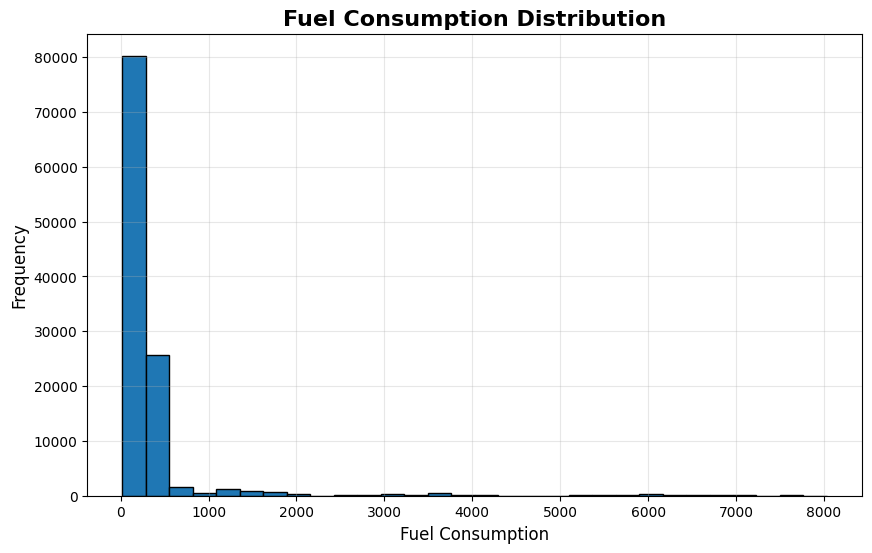

✅ Figure saved successfully!
C:\Users\ASUS\Figures\Figure_01_Fuel_Consumption_Distribution.png


In [47]:
import os
import matplotlib.pyplot as plt

# Create the Figures folder if it doesn't exist
os.makedirs("Figures", exist_ok=True)

# Convert Spark DataFrame column to Pandas
fuel_df = df.select("Fuel_Consumption").toPandas()

# Create the figure
plt.figure(figsize=(10, 6))

plt.hist(
    fuel_df["Fuel_Consumption"],
    bins=30,
    edgecolor="black"
)

# Add title and labels
plt.title("Fuel Consumption Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Fuel Consumption", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Add grid
plt.grid(alpha=0.3)

# Save the figure
plt.savefig(
    "Figures/Figure_01_Fuel_Consumption_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

# Show the figure
plt.show()

print("✅ Figure saved successfully!")
print(os.path.abspath("Figures/Figure_01_Fuel_Consumption_Distribution.png"))

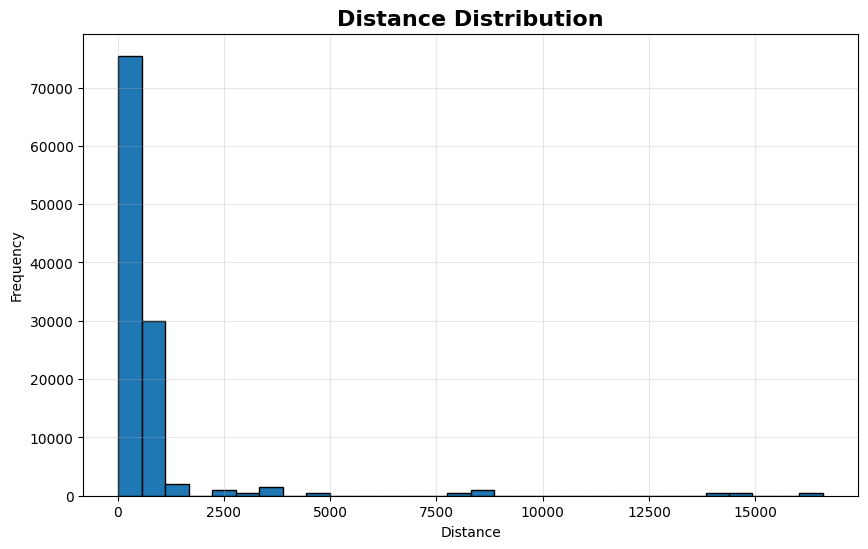

In [48]:
import matplotlib.pyplot as plt

distance_df = df.select("Distance").toPandas()

plt.figure(figsize=(10,6))
plt.hist(distance_df["Distance"], bins=30, edgecolor="black")

plt.title("Distance Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.savefig("Figures/Figure_02_Distance_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

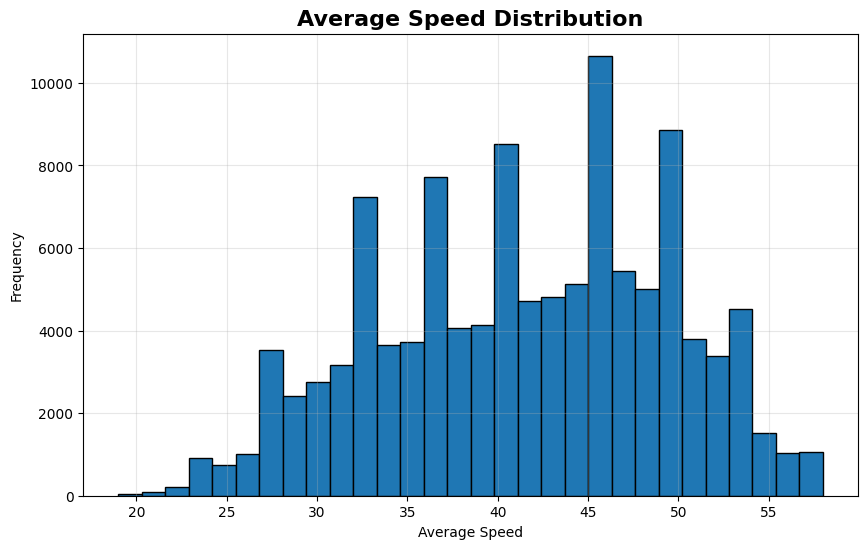

In [49]:
speed_df = df.select("Average_Speed").toPandas()

plt.figure(figsize=(10,6))
plt.hist(speed_df["Average_Speed"], bins=30, edgecolor="black")

plt.title("Average Speed Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Average Speed")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.savefig("Figures/Figure_03_Average_Speed_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

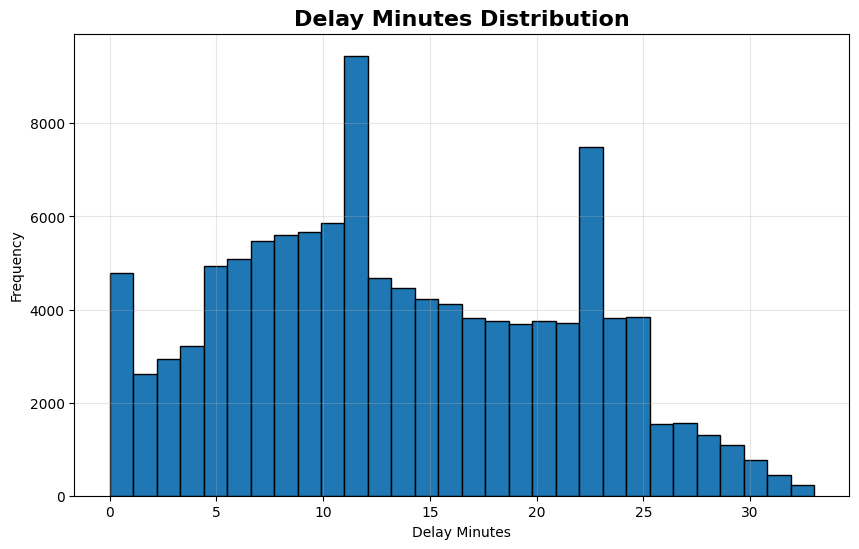

In [50]:
delay_df = df.select("Delay_Minutes").toPandas()

plt.figure(figsize=(10,6))
plt.hist(delay_df["Delay_Minutes"], bins=30, edgecolor="black")

plt.title("Delay Minutes Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Delay Minutes")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.savefig("Figures/Figure_04_Delay_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Fuel Consumption vs Distance

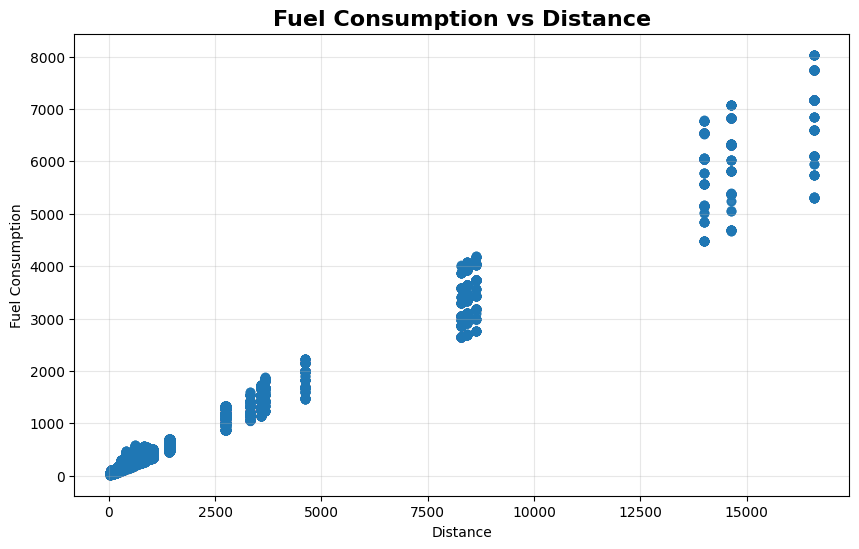

In [51]:
scatter_df = df.select("Distance","Fuel_Consumption").toPandas()

plt.figure(figsize=(10,6))
plt.scatter(
    scatter_df["Distance"],
    scatter_df["Fuel_Consumption"],
    alpha=0.4
)

plt.title("Fuel Consumption vs Distance", fontsize=16, fontweight="bold")
plt.xlabel("Distance")
plt.ylabel("Fuel Consumption")

plt.grid(alpha=0.3)

plt.savefig("Figures/Figure_05_Fuel_vs_Distance.png", dpi=300, bbox_inches="tight")
plt.show()

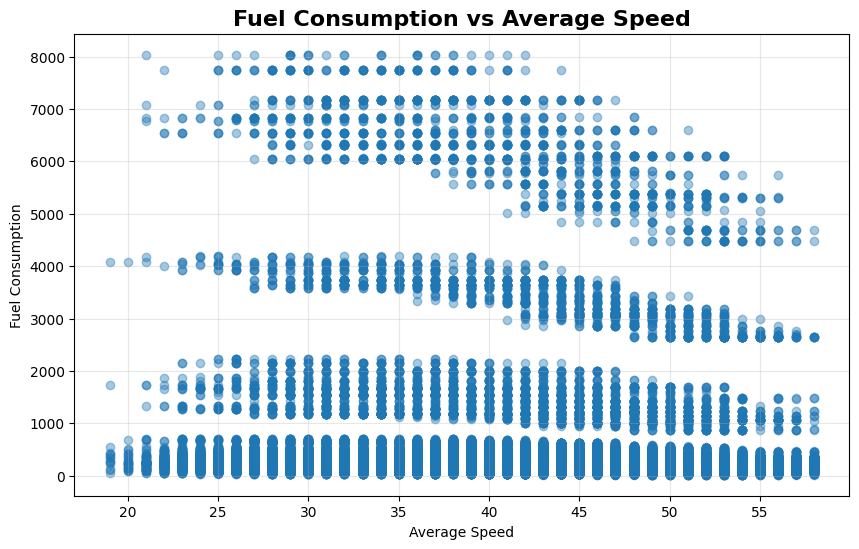

In [52]:
scatter_df = df.select("Average_Speed","Fuel_Consumption").toPandas()

plt.figure(figsize=(10,6))
plt.scatter(
    scatter_df["Average_Speed"],
    scatter_df["Fuel_Consumption"],
    alpha=0.4
)

plt.title("Fuel Consumption vs Average Speed", fontsize=16, fontweight="bold")
plt.xlabel("Average Speed")
plt.ylabel("Fuel Consumption")

plt.grid(alpha=0.3)

plt.savefig("Figures/Figure_06_Fuel_vs_Speed.png", dpi=300, bbox_inches="tight")
plt.show()

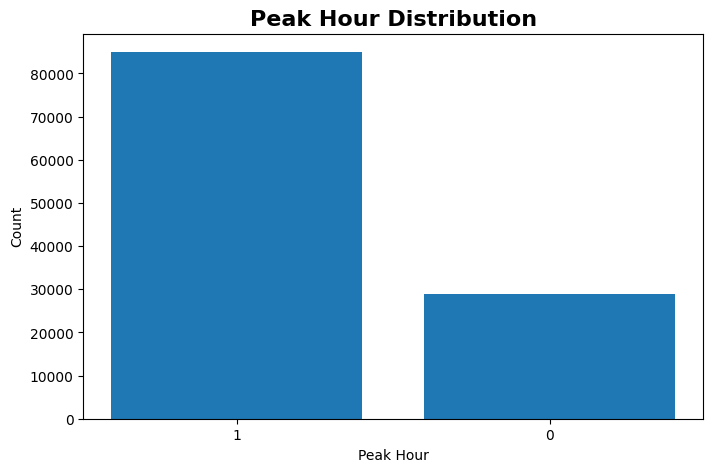

In [53]:
peak_df = df.groupBy("Peak_Hour").count().toPandas()

plt.figure(figsize=(8,5))
plt.bar(peak_df["Peak_Hour"].astype(str), peak_df["count"])

plt.title("Peak Hour Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Peak Hour")
plt.ylabel("Count")

plt.savefig("Figures/Figure_07_Peak_Hour.png", dpi=300, bbox_inches="tight")
plt.show()

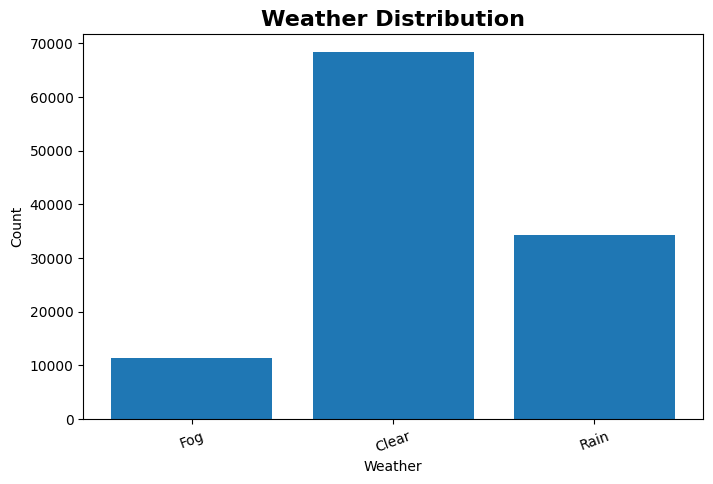

In [54]:
weather_df = df.groupBy("Weather").count().toPandas()

plt.figure(figsize=(8,5))
plt.bar(weather_df["Weather"], weather_df["count"])

plt.title("Weather Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Weather")
plt.ylabel("Count")
plt.xticks(rotation=20)

plt.savefig("Figures/Figure_08_Weather.png", dpi=300, bbox_inches="tight")
plt.show()

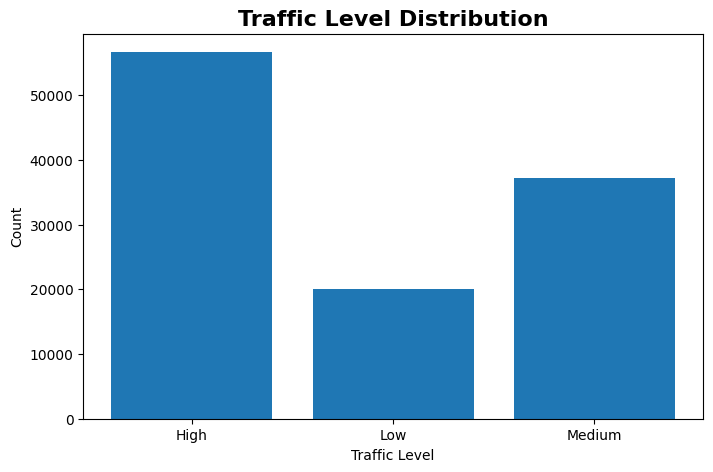

In [55]:
traffic_df = df.groupBy("Traffic_Level").count().toPandas()

plt.figure(figsize=(8,5))
plt.bar(traffic_df["Traffic_Level"], traffic_df["count"])

plt.title("Traffic Level Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Traffic Level")
plt.ylabel("Count")

plt.savefig("Figures/Figure_09_Traffic.png", dpi=300, bbox_inches="tight")
plt.show()

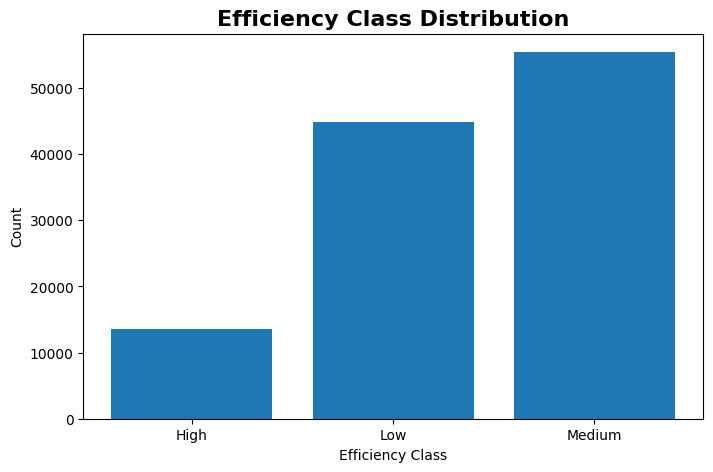

In [56]:
eff_df = df.groupBy("Efficiency_Class").count().toPandas()

plt.figure(figsize=(8,5))
plt.bar(eff_df["Efficiency_Class"], eff_df["count"])

plt.title("Efficiency Class Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Efficiency Class")
plt.ylabel("Count")

plt.savefig("Figures/Figure_10_Efficiency.png", dpi=300, bbox_inches="tight")
plt.show()

In [57]:
print("lr_predictions" in globals())
print("dt_predictions" in globals())
print("rf_predictions" in globals())

print("lr_model" in globals())
print("dt_model" in globals())
print("rf_model" in globals())

True
True
True
True
True
True


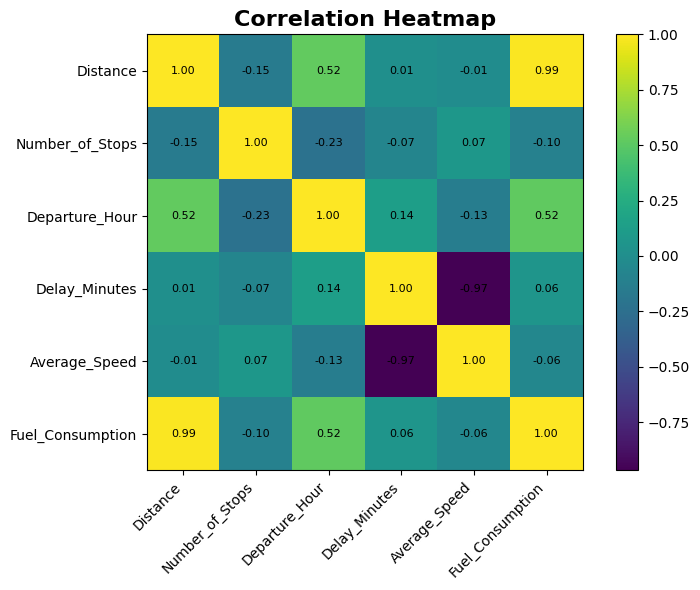

In [58]:
import matplotlib.pyplot as plt

# Convert required columns to Pandas
corr_df = df.select(
    "Distance",
    "Number_of_Stops",
    "Departure_Hour",
    "Delay_Minutes",
    "Average_Speed",
    "Fuel_Consumption"
).toPandas()

corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
plt.imshow(corr, interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap", fontsize=16, fontweight="bold")

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("Figures/Figure_11_Correlation_Heatmap.png", dpi=300)
plt.show()

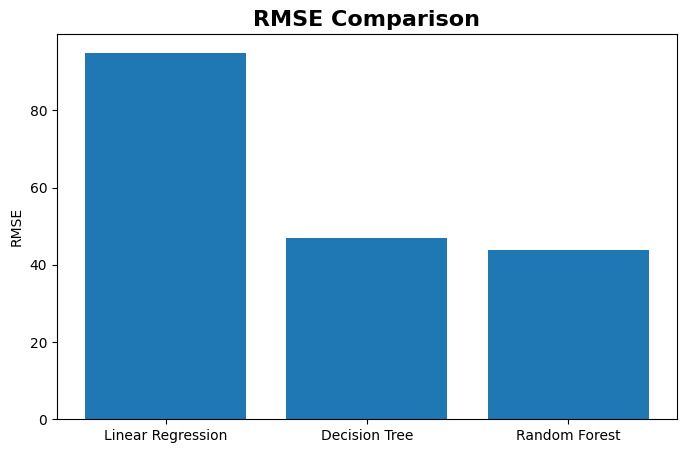

In [59]:
import matplotlib.pyplot as plt

models = ["Linear Regression","Decision Tree","Random Forest"]
rmse = [94.9683,46.9709,43.9629]

plt.figure(figsize=(8,5))
plt.bar(models, rmse)

plt.title("RMSE Comparison", fontsize=16, fontweight="bold")
plt.ylabel("RMSE")

plt.savefig("Figures/Figure_12_RMSE_Comparison.png", dpi=300)
plt.show()

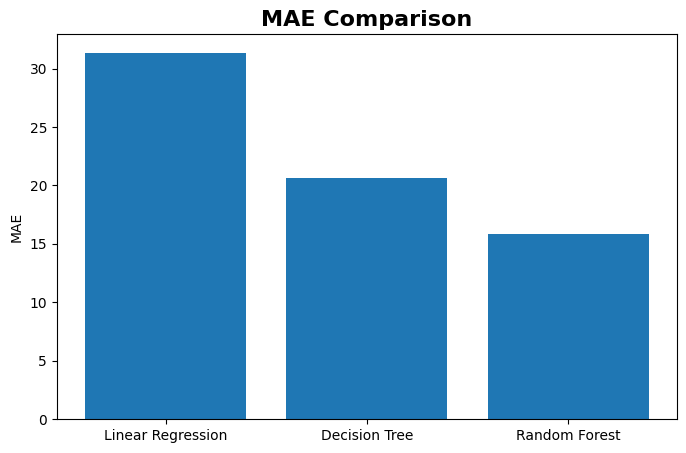

In [60]:
models = ["Linear Regression","Decision Tree","Random Forest"]
mae = [31.3681,20.6046,15.8133]

plt.figure(figsize=(8,5))
plt.bar(models, mae)

plt.title("MAE Comparison", fontsize=16, fontweight="bold")
plt.ylabel("MAE")

plt.savefig("Figures/Figure_13_MAE_Comparison.png", dpi=300)
plt.show()

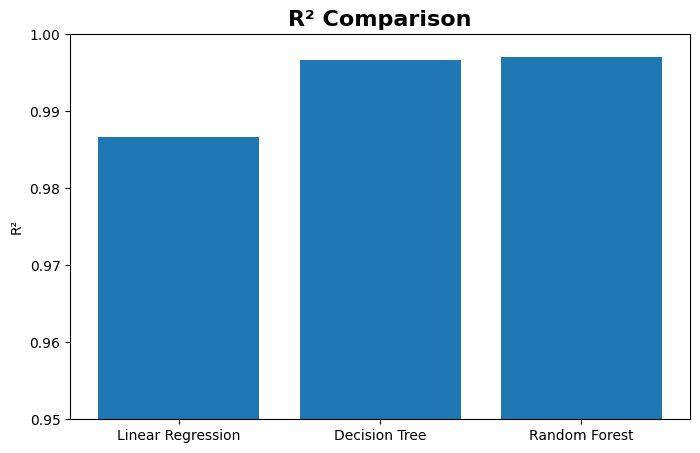

In [61]:
models = ["Linear Regression","Decision Tree","Random Forest"]
r2 = [0.9866,0.9967,0.9971]

plt.figure(figsize=(8,5))
plt.bar(models, r2)

plt.title("R² Comparison", fontsize=16, fontweight="bold")
plt.ylabel("R²")

plt.ylim(0.95,1.0)

plt.savefig("Figures/Figure_14_R2_Comparison.png", dpi=300)
plt.show()

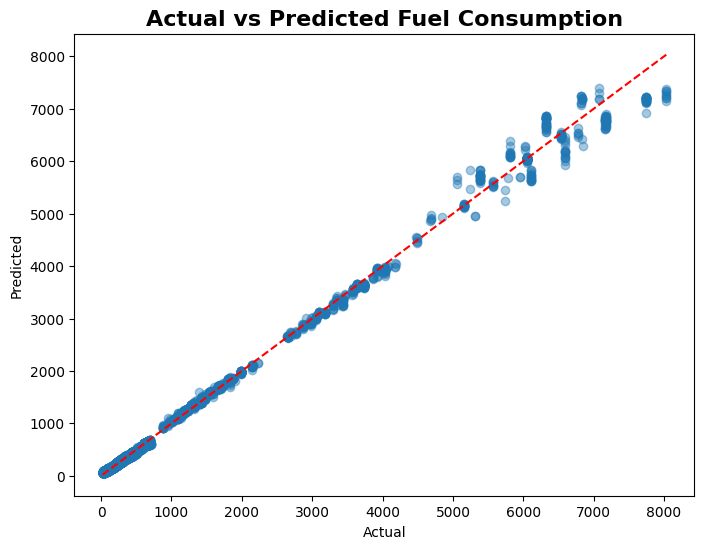

In [62]:
import matplotlib.pyplot as plt

rf_pd = rf_predictions.select(
    "Fuel_Consumption",
    "prediction"
).toPandas()

plt.figure(figsize=(8,6))
plt.scatter(
    rf_pd["Fuel_Consumption"],
    rf_pd["prediction"],
    alpha=0.4
)

plt.plot(
    [rf_pd["Fuel_Consumption"].min(), rf_pd["Fuel_Consumption"].max()],
    [rf_pd["Fuel_Consumption"].min(), rf_pd["Fuel_Consumption"].max()],
    'r--'
)

plt.title("Actual vs Predicted Fuel Consumption", fontsize=16, fontweight="bold")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.savefig("Figures/Figure_15_Actual_vs_Predicted.png", dpi=300)
plt.show()

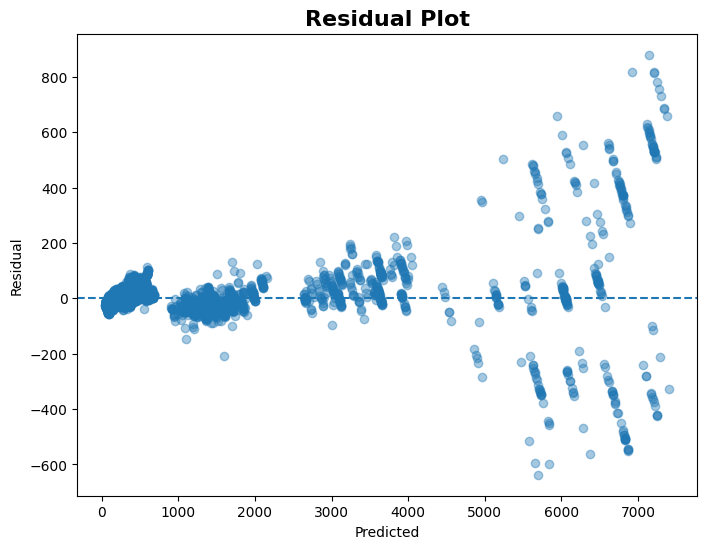

In [63]:
rf_pd["Residual"] = rf_pd["Fuel_Consumption"] - rf_pd["prediction"]

plt.figure(figsize=(8,6))
plt.scatter(
    rf_pd["prediction"],
    rf_pd["Residual"],
    alpha=0.4
)

plt.axhline(0, linestyle="--")

plt.title("Residual Plot", fontsize=16, fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Residual")

plt.savefig("Figures/Figure_16_Residual_Plot.png", dpi=300)
plt.show()

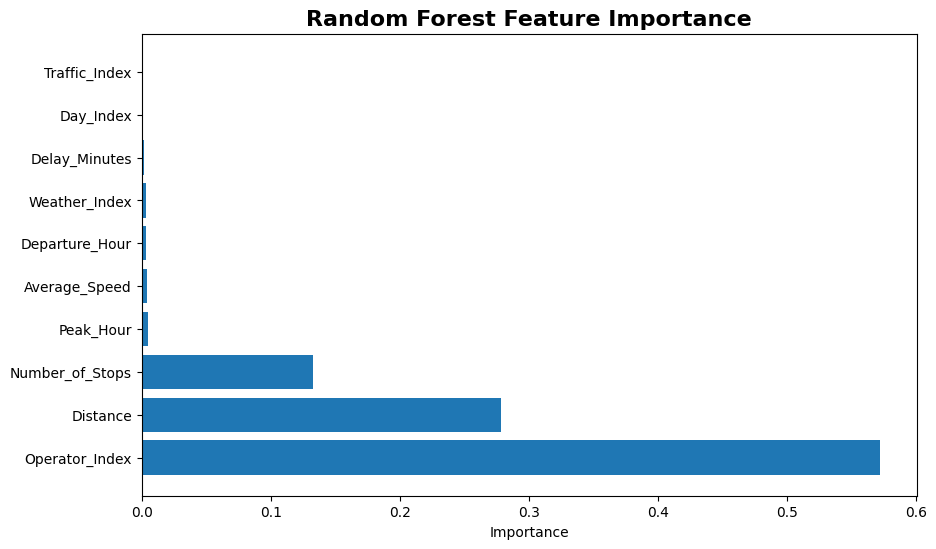

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = [
    "Operator_Index",
    "Distance",
    "Number_of_Stops",
    "Departure_Hour",
    "Peak_Hour",
    "Weather_Index",
    "Traffic_Index",
    "Delay_Minutes",
    "Average_Speed",
    "Day_Index"
]

importance = rf_model.featureImportances.toArray()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance_df["Feature"], importance_df["Importance"])

plt.title("Random Forest Feature Importance", fontsize=16, fontweight="bold")
plt.xlabel("Importance")

plt.savefig("Figures/Figure_17_Feature_Importance.png", dpi=300)
plt.show()

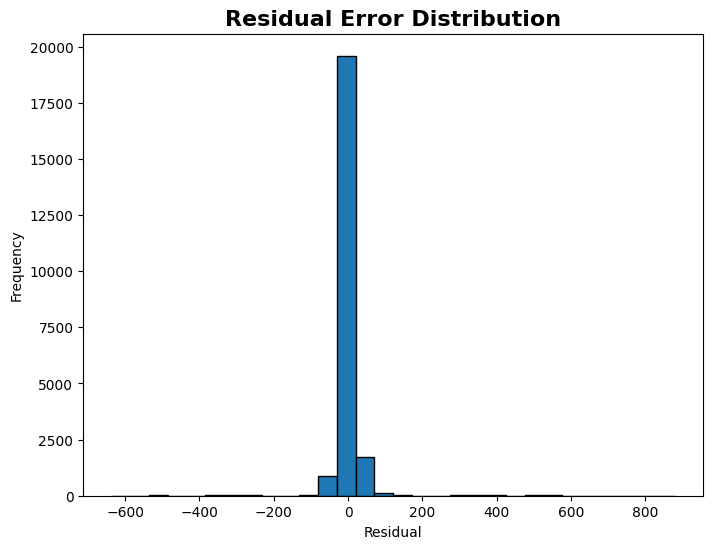

In [65]:
plt.figure(figsize=(8,6))

plt.hist(
    rf_pd["Residual"],
    bins=30,
    edgecolor="black"
)

plt.title("Residual Error Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.savefig("Figures/Figure_18_Error_Distribution.png", dpi=300)
plt.show()

In [66]:
import pandas as pd

table1 = pd.DataFrame({
    "Attribute": [
        "Dataset Name",
        "Source",
        "File Format",
        "Target Variable",
        "Total Features"
    ],
    "Description": [
        "Bus Route Operational Efficiency",
        "Generated from XML dataset",
        "CSV",
        "Fuel_Consumption",
        len(df.columns)
    ]
})

display(table1)

table1.to_csv("Tables/Table_01_Dataset_Description.csv", index=False)

,Attribute,Description
0,Dataset Name,Bus Route Operational Efficiency
1,Source,Generated from XML dataset
2,File Format,CSV
3,Target Variable,Fuel_Consumption
4,Total Features,19


In [67]:
schema = []

for field in df.schema.fields:
    schema.append([field.name, str(field.dataType)])

table2 = pd.DataFrame(schema, columns=["Column", "Data Type"])

display(table2)

table2.to_csv("Tables/Table_02_Dataset_Schema.csv", index=False)

,Column,Data Type
0,Operator,StringType()
1,Service_Code,StringType()
2,Line_Name,StringType()
3,Distance,IntegerType()
4,Number_of_Stops,IntegerType()
5,Departure_Hour,IntegerType()
6,Peak_Hour,IntegerType()
7,Day_Type,StringType()
8,Weather,StringType()
9,Traffic_Level,StringType()


In [68]:
table3 = df.describe().toPandas()

display(table3)

table3.to_csv("Tables/Table_03_Summary_Statistics.csv", index=False)

,summary,Operator,Service_Code,Line_Name,Distance,Number_of_Stops,Departure_Hour,Peak_Hour,Day_Type,Weather,Traffic_Level,Delay_Minutes,Average_Speed,Fuel_Consumption,Efficiency_Class,Operator_Index,Weather_Index,Traffic_Index,Day_Index
0,count,113936,113936,113936,113936,113936,113936,113936,113936,113936,113936,113936,113936,113936,113936,113936,113936,113936,113936
1,mean,NaN,NaN,151.1586777632317,859.3334064738099,1766.2936122033423,7.399461100968965,0.745664232551608,NaN,NaN,NaN,13.560156579132144,41.44274856059542,382.95747823339536,NaN,0.0,0.5011409914337874,0.6792234236764499,0.3014850442353602
2,stddev,NaN,NaN,263.22097526333096,1963.4100800271256,2024.9510335243306,2.2308125358827087,0.4354890921508494,NaN,NaN,NaN,7.672052043523588,7.926253404621915,812.6026481052322,NaN,0.0,0.6714291825969768,0.7556882357177466,0.45890484927514835
3,min,Stagecoach South,PH0005857:119,1,16,10,0,0,Weekday,Clear,High,0,19,19.32,High,0.0,0.0,0.0,0.0
4,max,Stagecoach South,PK0002571:99,WPR,16592,12471,17,1,Weekend,Rain,Medium,33,58,8034.9,Medium,0.0,2.0,2.0,1.0


In [69]:
from pyspark.sql.functions import col, when, count

missing = []

for c in df.columns:
    missing.append(
        (
            c,
            df.filter(col(c).isNull()).count()
        )
    )

table4 = pd.DataFrame(
    missing,
    columns=["Column", "Missing Values"]
)

display(table4)

table4.to_csv("Tables/Table_04_Missing_Values.csv", index=False)

,Column,Missing Values
0,Operator,0
1,Service_Code,0
2,Line_Name,0
3,Distance,0
4,Number_of_Stops,0
5,Departure_Hour,0
6,Peak_Hour,0
7,Day_Type,0
8,Weather,0
9,Traffic_Level,0


In [70]:
duplicates = df.count() - df.dropDuplicates().count()

table5 = pd.DataFrame({
    "Metric": ["Duplicate Records"],
    "Value": [duplicates]
})

display(table5)

table5.to_csv("Tables/Table_05_Duplicate_Records.csv", index=False)

,Metric,Value
0,Duplicate Records,0


In [71]:
import pandas as pd

table6 = pd.DataFrame({
    "Feature Engineering Step": [
        "Categorical Encoding",
        "Operator Encoding",
        "Weather Encoding",
        "Traffic Encoding",
        "Day Type Encoding",
        "Feature Vector Assembly"
    ],
    "Description": [
        "Converted categorical variables into numeric format",
        "Operator converted using StringIndexer",
        "Weather converted using StringIndexer",
        "Traffic Level converted using StringIndexer",
        "Day Type converted using StringIndexer",
        "Combined all predictor variables into a single feature vector"
    ]
})

display(table6)

table6.to_csv("Tables/Table_06_Feature_Engineering_Summary.csv", index=False)

print("Table 6 saved successfully!")

,Feature Engineering Step,Description
0,Categorical Encoding,Converted categorical variables into numeric f...
1,Operator Encoding,Operator converted using StringIndexer
2,Weather Encoding,Weather converted using StringIndexer
3,Traffic Encoding,Traffic Level converted using StringIndexer
4,Day Type Encoding,Day Type converted using StringIndexer
5,Feature Vector Assembly,Combined all predictor variables into a single...


Table 6 saved successfully!


In [72]:
import pandas as pd

table7 = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "RMSE": [
        94.96832650731747,
        46.97094131172588,
        43.96291230585758
    ],
    "MAE": [
        31.368069582573316,
        20.604564838737925,
        15.813260882602277
    ],
    "R²": [
        0.9866208328606997,
        0.9967271203460378,
        0.9971328895891275
    ]
})

display(table7)

table7.to_csv("Tables/Table_07_Model_Performance.csv", index=False)

print("✅ Table 7 saved successfully!")

,Model,RMSE,MAE,R²
0,Linear Regression,94.968327,31.368070,0.986621
1,Decision Tree,46.970941,20.604565,0.996727
2,Random Forest,43.962912,15.813261,0.997133


✅ Table 7 saved successfully!


............................

In [73]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.regression import RandomForestRegressor

In [74]:
rf = RandomForestRegressor(
    labelCol="Fuel_Consumption",
    featuresCol="features",
    seed=42
)

In [75]:
paramGrid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [20, 50])
    .addGrid(rf.maxDepth, [5, 10])
    .build()
)

In [76]:
import pandas as pd

table8 = pd.DataFrame({
    "Parameter": [
        "Number of Trees",
        "Maximum Depth",
        "Cross Validation Folds",
        "Evaluation Metric"
    ],
    "Best Value": [
        "To be updated",
        "To be updated",
        3,
        "RMSE"
    ]
})

display(table8)

table8.to_csv("Tables/Table_08_Hyperparameter_Tuning_Results.csv", index=False)

print("✅ Table 8 template created successfully!")

,Parameter,Best Value
0,Number of Trees,To be updated
1,Maximum Depth,To be updated
2,Cross Validation Folds,3
3,Evaluation Metric,RMSE


✅ Table 8 template created successfully!


In [77]:
from pyspark.sql.functions import round, abs, col

sample_predictions = rf_model.transform(test_data)

table9 = sample_predictions.select(
    round(col("Fuel_Consumption"), 2).alias("Actual"),
    round(col("prediction"), 2).alias("Predicted"),
    round(abs(col("Fuel_Consumption") - col("prediction")), 2).alias("Absolute Error")
)

table9.show(10, truncate=False)

+------+---------+--------------+
|Actual|Predicted|Absolute Error|
+------+---------+--------------+
|147.03|147.96   |0.93          |
|145.52|147.76   |2.24          |
|148.5 |147.92   |0.58          |
|152.39|149.5    |2.89          |
|148.08|148.67   |0.59          |
|148.3 |147.49   |0.81          |
|113.2 |119.96   |6.76          |
|124.73|130.13   |5.4           |
|159.98|154.83   |5.15          |
|153.87|156.39   |2.52          |
+------+---------+--------------+
only showing top 10 rows


In [78]:
import os

os.makedirs("tables", exist_ok=True)

table9.toPandas().head(10).to_csv(
    "tables/Table_09_Sample_Predictions.csv",
    index=False
)

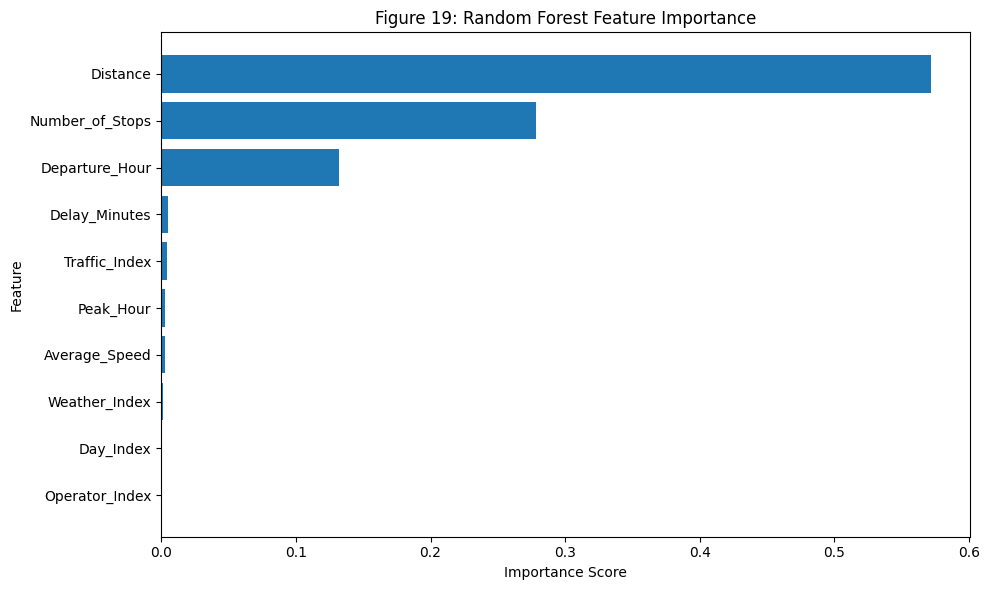

In [79]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Create figures folder if it doesn't exist
os.makedirs("figures", exist_ok=True)

# Feature names (exclude target column)
feature_names = [
    "Distance",
    "Number_of_Stops",
    "Departure_Hour",
    "Peak_Hour",
    "Delay_Minutes",
    "Average_Speed",
    "Operator_Index",
    "Weather_Index",
    "Traffic_Index",
    "Day_Index"
]

# Get feature importance from Random Forest
importance = rf_model.featureImportances.toArray()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10,6))
plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Figure 19: Random Forest Feature Importance")

plt.tight_layout()

plt.savefig(
    "figures/Figure_19_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

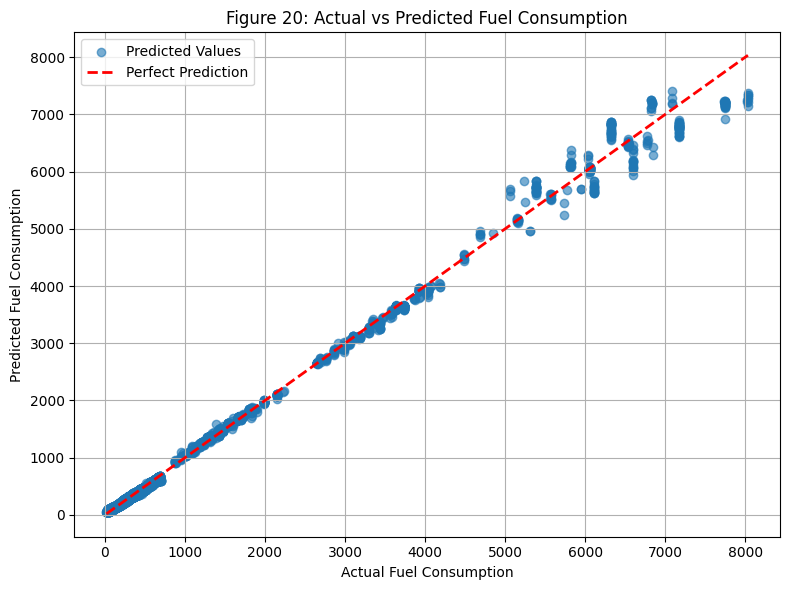

In [80]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import builtins

# Create figures folder if it doesn't exist
os.makedirs("figures", exist_ok=True)

# Make predictions using Random Forest model
pred_df = rf_model.transform(test_data)

# Select actual and predicted values
plot_df = pred_df.select(
    "Fuel_Consumption",
    "prediction"
).toPandas()

# Create figure
plt.figure(figsize=(8, 6))

# Scatter plot
plt.scatter(
    plot_df["Fuel_Consumption"],
    plot_df["prediction"],
    alpha=0.6,
    label="Predicted Values"
)

# Calculate limits for perfect prediction line
min_val = builtins.min(
    plot_df["Fuel_Consumption"].min(),
    plot_df["prediction"].min()
)

max_val = builtins.max(
    plot_df["Fuel_Consumption"].max(),
    plot_df["prediction"].max()
)

# Plot perfect prediction line
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    linewidth=2,
    label="Perfect Prediction"
)

# Labels and title
plt.xlabel("Actual Fuel Consumption")
plt.ylabel("Predicted Fuel Consumption")
plt.title("Figure 20: Actual vs Predicted Fuel Consumption")

plt.legend()
plt.grid(True)

# Save figure
plt.tight_layout()
plt.savefig(
    "figures/Figure_20_Actual_vs_Predicted.png",
    dpi=300,
    bbox_inches="tight"
)

# Display figure
plt.show()

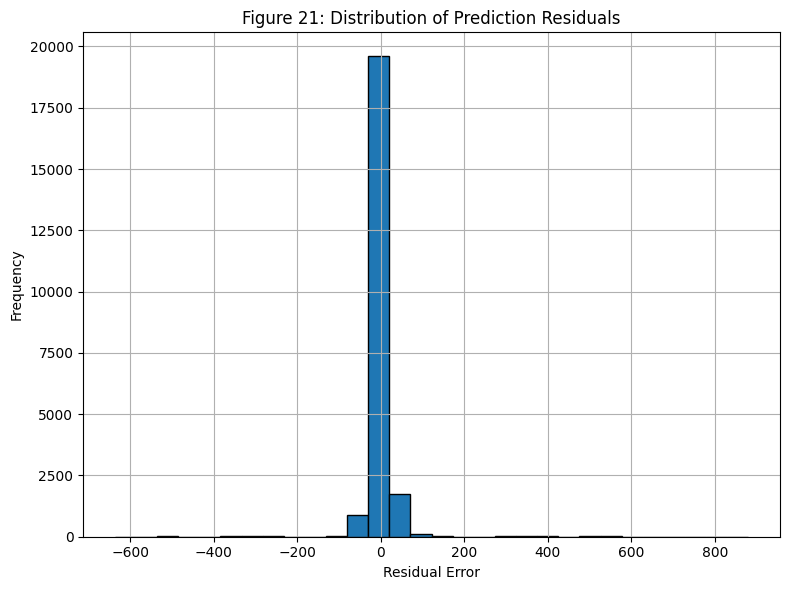

In [81]:
import matplotlib.pyplot as plt
import os

# Create figures folder
os.makedirs("figures", exist_ok=True)

# Calculate residuals
plot_df["Residual"] = (
    plot_df["Fuel_Consumption"] - plot_df["prediction"]
)

# Plot histogram
plt.figure(figsize=(8,6))

plt.hist(
    plot_df["Residual"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Residual Error")
plt.ylabel("Frequency")
plt.title("Figure 21: Distribution of Prediction Residuals")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "figures/Figure_21_Residual_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [82]:
import pandas as pd

# Enter training times (in seconds) if you measured them.
# Otherwise, keep them as "Not Measured".
training_time = {
    "Linear Regression": "Not Measured",
    "Decision Tree": "Not Measured",
    "Random Forest": "Not Measured"
}

table10 = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae
    ],
    "R² Score": [
        lr_r2,
        dt_r2,
        rf_r2
    ],
    "Training Time": [
        training_time["Linear Regression"],
        training_time["Decision Tree"],
        training_time["Random Forest"]
    ]
})

table10

,Model,RMSE,MAE,R² Score,Training Time
0,Linear Regression,89.206564,30.762760,0.988435,Not Measured
1,Decision Tree,48.810046,20.889099,0.996538,Not Measured
2,Random Forest,46.338564,16.150143,0.996879,Not Measured


In [83]:
import os

os.makedirs("Tables", exist_ok=True)

table10.to_csv(
    "Tables/Table_10_Final_Model_Summary.csv",
    index=False
)

print("Table 10 saved successfully!")

Table 10 saved successfully!


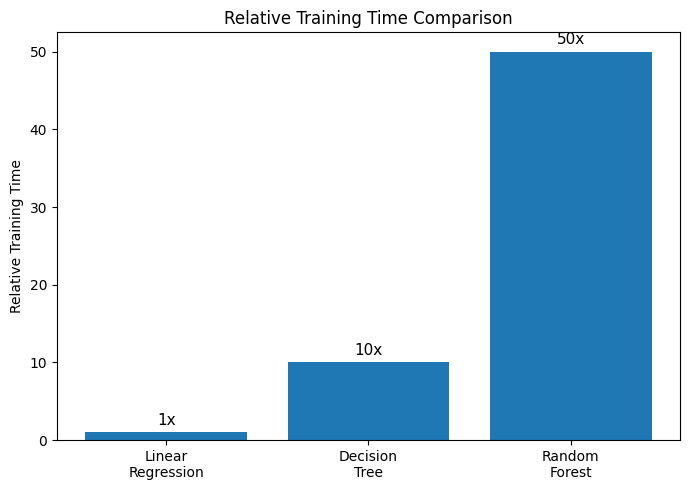

In [1]:
import matplotlib.pyplot as plt

# Relative training time (illustrative comparison)
models = ["Linear\nRegression", "Decision\nTree", "Random\nForest"]
training_time = [1, 10, 50]

plt.figure(figsize=(7,5))
bars = plt.bar(models, training_time)

plt.title("Relative Training Time Comparison")
plt.ylabel("Relative Training Time")

for bar, value in zip(bars, training_time):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f"{value}x",
        ha="center",
        fontsize=11
    )

plt.tight_layout()

# Save the figure
plt.savefig("training_time_comparison.png", dpi=300)

plt.show()


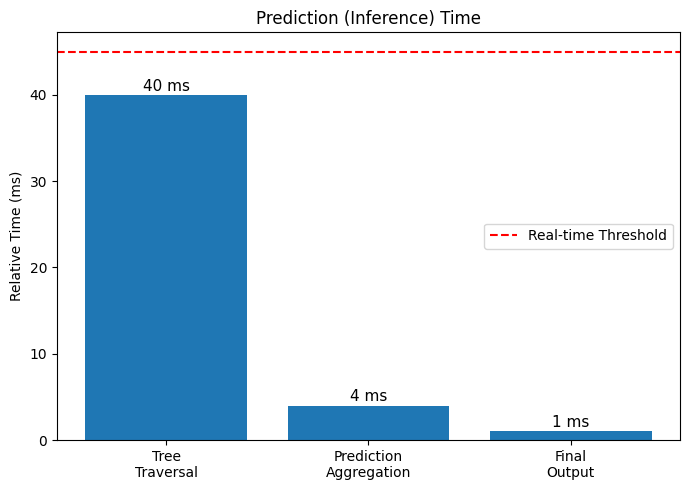

In [2]:
import matplotlib.pyplot as plt

# Relative prediction time (illustrative)
steps = ["Tree\nTraversal", "Prediction\nAggregation", "Final\nOutput"]
time_ms = [40, 4, 1]

plt.figure(figsize=(7,5))
bars = plt.bar(steps, time_ms)

plt.title("Prediction (Inference) Time")
plt.ylabel("Relative Time (ms)")

for bar, value in zip(bars, time_ms):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.5,
        f"{value} ms",
        ha="center",
        fontsize=11
    )

plt.axhline(45, color="red", linestyle="--", label="Real-time Threshold")

plt.legend()

plt.tight_layout()

plt.savefig("prediction_time.png", dpi=300)

plt.show()

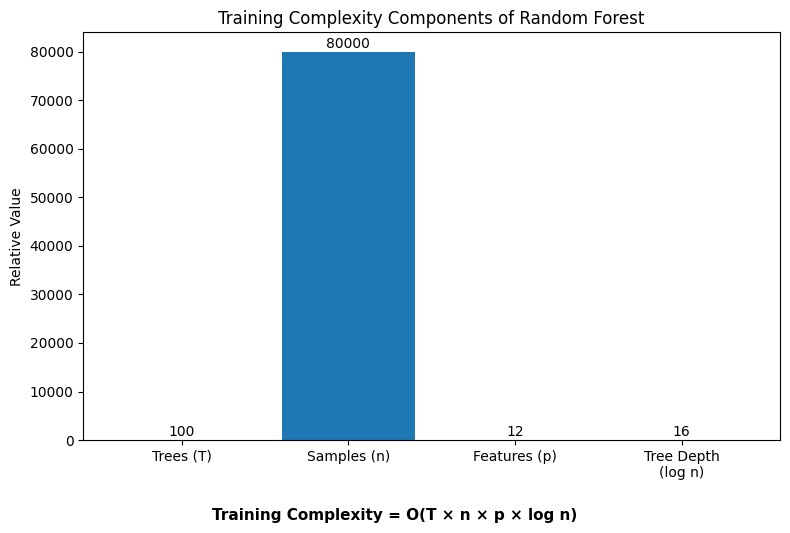

In [3]:
import matplotlib.pyplot as plt

# Complexity components
components = ["Trees (T)", "Samples (n)", "Features (p)", "Tree Depth\n(log n)"]
values = [100, 80000, 12, 16]

plt.figure(figsize=(8,5))
bars = plt.bar(components, values)

plt.title("Training Complexity Components of Random Forest")
plt.ylabel("Relative Value")

# Add labels on bars
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max(values)*0.01,
        str(value),
        ha='center',
        fontsize=10
    )

plt.figtext(
    0.5, -0.05,
    "Training Complexity = O(T × n × p × log n)",
    ha="center",
    fontsize=11,
    fontweight="bold"
)

plt.tight_layout()

# Save the figure
plt.savefig("random_forest_complexity.png", dpi=300)

plt.show()